In [5]:
import sys
sys.path.insert(0, '../Modules/')
import numpy as np
import torch
from sklearn.decomposition import PCA
from index_set import index_set
from families import JacobiPolynomials
from HAlphaBasisCompressor import HAlphaBasisCompressor
from OperatorLearningPlotter import OperatorLearningPlotter
from Empirical_Operator_WLS import Empirical_Operator_WLS

def err_wrt_alpha(alpha):
    ### Dimension Reduction parameters
    nPCA_Max =  750              # Maximum number of PCA modes allowed
    PCA_Threshold = 0.995        # Amount of energy to retain in input space
    #alpha = -4                  # Sobolev Parameter for output space: 0 = L^2, 1 = H^1, etc.  
    HAlpha_Threshold = 0.999     # Amount of energy to retain in output data

    ### Index set params
    HC_Param = 28                # Hyperbolic Cross Parameter ~ set large to reach max size
    max_poly_indx = 10           # Maximum degree of (univariate) polynomial in gPC
    N_max = 50000                 # Maximum size of (effective) hyperbolic index set
    anisotropic = True           # Weight poly-deg multi-indices by normalized sing val of input dat    

    # Scale input data to lie in [-1,1]: 
    normalization = 'uniform'    # Scale all input data uniformly, to maintain relative magnitudes

    # Spatial data is on 128 x 128 grid
    train_dat = torch.load('Spatial_Data/nsforcing_train_128.pt', weights_only=True)
    test_dat  = torch.load('Spatial_Data/nsforcing_test_128.pt', weights_only=True )
    X_train_grid = train_dat['x'].numpy()
    Y_train_grid = train_dat['y'].numpy()
    X_test_grid  = test_dat['x'].numpy()
    Y_test_grid  = test_dat['y'].numpy()

    # Reshape X grid data to vector for PCA
    X_train = X_train_grid.reshape(X_train_grid.shape[0],-1)
    X_test  = X_test_grid.reshape(X_test_grid.shape[0], -1) 

    # Adaptively choose number of PCA coeffcients 
    pca = PCA(n_components = nPCA_Max)
    pca.fit(X_train)
    nPCA_X = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), PCA_Threshold)+1

    # Preform PCA to lower dimensionality
    pca_X = PCA(n_components=nPCA_X)
    input_data_raw = pca_X.fit_transform(X_train)
    input_data_raw_test = pca_X.transform(X_test)

    # Scale input coefficients to lie in [-1,1] for Jacobi Polynomial Domain 
    if normalization == 'uniform':
        linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test))))
        input_data = input_data_raw / linf
        input_test = input_data_raw_test / linf

    elif normalization == 'entrywise': 
        input_data = np.zeros_like(input_data_raw)
        input_test = np.zeros_like(input_data_raw_test)
        for col in range(nPCA_X):
            linf = np.max(np.abs(np.vstack((input_data_raw, input_data_raw_test)))[:,col])
            input_data[:,col] = input_data_raw[:,col]/linf
            input_test[:,col] = input_data_raw_test[:,col]/linf
    else:
        raise ValueError("Normalization must be either 'uniform' for 'entrywise'")

    # Project Y Data onto H^alpha subspace:
    compressor = HAlphaBasisCompressor(N=Y_train_grid.shape[1], threshold=HAlpha_Threshold, alpha = alpha)
    compressor.fit(Y_train_grid) 
    output_data = np.array([compressor.project(snapshot) for snapshot in Y_train_grid])
    output_test = np.array([compressor.project(snapshot) for snapshot in Y_test_grid])

    ### Fit Jacobi Parameters Defining Measure on Input Space by Matching Empirical Variance 
    VarX = np.var(input_data, axis = 0)
    VarX_safe = np.clip(VarX, 1e-10, None)  # avoid blow up for near zero variance
    jParams = ((1/VarX) - 3)/2   

    # Define index set weights
    idx_weights = pca_X.singular_values_ / pca_X.singular_values_[0] if anisotropic else np.ones(nPCA_X)

    # Define polynomial part of index set
    PolyIdxs = index_set(d = nPCA_X, param = HC_Param, max_index = max_poly_indx, weights = idx_weights, max_size = N_max, type = 'hc' )
    N = PolyIdxs.shape[0]
    M = int(N*np.log(N))

    # Init Operator Learning Class 
    wls_operator = Empirical_Operator_WLS(
        input_data = input_data, 
        output_data = output_data, 
        index_set = PolyIdxs, 
        jacobi_params = jParams)

    # Fit Operator to Training Data 
    wls_operator.fit(M)

    # Evaluate Operator on Training Data
    ApproxOpSamp = wls_operator.predict_on_fit_samples()
    err, rel_err = wls_operator.compute_fit_sample_errors()

    # Evaluate Operator on Testing Data
    ApproxOpTest = wls_operator.predict(input_test)
    test_err, rel_test_err = wls_operator.compute_errors(input_test, output_test)

    M_test = 2000
    approx_spatial_test = np.zeros((M_test,128,128))
    true_spatial_test = np.zeros((M_test,128,128))
    for m in range(M_test):
        approx_spatial_test[m, :, :] = compressor.reconstruct_spatial(ApproxOpTest[m])
        true_spatial_test[m,:,:] = compressor.reconstruct_spatial(output_test[m])

    masked_rel_err_per_samp = []
    for i in range(M_test):
        u_true = true_spatial_test[i]
        u_pred = approx_spatial_test[i]
        mask = np.abs(u_true) > 1e-3
        rel_err = np.abs(u_true-u_pred) / np.abs(u_true)
        masked_rel_err = np.mean(rel_err[mask])
        masked_rel_err_per_samp.append(masked_rel_err)
    masked_rel_err_per_samp = np.array(masked_rel_err_per_samp)

    mean_abs_err_per_samp = np.mean(
        np.abs(true_spatial_test - approx_spatial_test), axis = (1,2)
    )

    return np.mean(rel_test_err), np.mean(masked_rel_err_per_samp), np.mean(mean_abs_err_per_samp), compressor.M, N

In [14]:
alphas = [-5,-3,-1,0,1,3,5]
rel_Ha_errs = []
rel_spat_errs = []
abs_spat_errs = []
Y_dims = []
Ns = []
for alpha in alphas: 
    Herr, Rerr, Aerr, dim, N = err_wrt_alpha(alpha)
    rel_Ha_errs.append(Herr)
    rel_spat_errs.append(Rerr)
    abs_spat_errs.append(Aerr)
    Y_dims.append(dim)
    Ns.append(N)
np.save('Data/alphas.npy', alphas)
np.save('Data/rel_Ha_errs.npy', rel_Ha_errs)
np.save('Data/rel_spat_errs.npy', rel_spat_errs)
np.save('Data/abs_spat_errs.npy', abs_spat_errs)
np.save('Data/Y_dims', Y_dims)
np.save('Data/Ns.npy', Ns)

/var/folders/b7/7h1fh2891rb_lczn9m2_13mw0000gn/T/ipykernel_24284/1059874493.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko--" (-> color='k'). The keyword argument will take precedence.
  ax[0].plot(alphas, rel_Ha_errs, 'ko--',label = r"Relative $H^{\alpha}$ Error", color = 'firebrick')


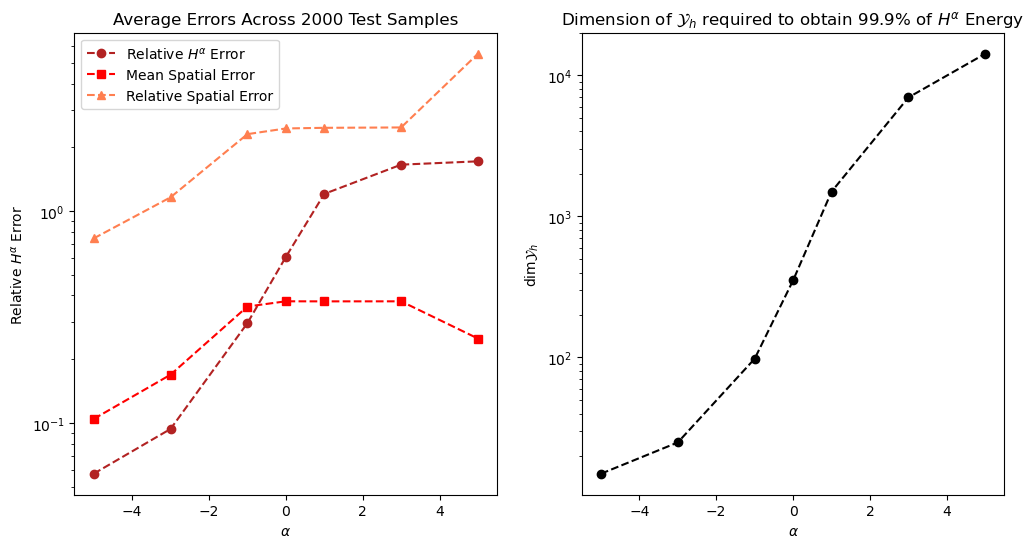

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import matplotlib as mpl


alphas = np.load('Data/alphas.npy')
rel_Ha_errs = np.load('Data/rel_Ha_errs.npy')
rel_spat_errs = np.load('Data/rel_spat_errs.npy')
abs_spat_errs = np.load('Data/abs_spat_errs.npy')
Y_dims = np.load('Data/Y_dims.npy')
Ns = np.load('Data/Ns.npy')


fig,ax = plt.subplots(ncols = 2, figsize = (12,6))
ax[0].plot(alphas, rel_Ha_errs, 'ko--',label = r"Relative $H^{\alpha}$ Error", color = 'firebrick')
ax[0].plot(alphas,abs_spat_errs, 's--', label = r"Mean Spatial Error", color = 'red')
ax[0].plot(alphas, rel_spat_errs, '^--', label = r"Relative Spatial Error", color = 'coral')
ax[0].set(title = "Average Errors Across 2000 Test Samples")
ax[0].legend(loc = 'best')
ax[0].set(xlabel=r"$\alpha$", yscale='log', ylabel = r"Relative $H^{\alpha}$ Error")

ax[1].plot(alphas, Y_dims, "o--", color = 'black')
ax[1].set(xlabel = r"$\alpha$", ylabel = r"$\mathrm{dim}\mathcal{Y}_h$", yscale = 'log')
ax[1].set(title = r"Dimension of $\mathcal{Y}_h$ required to obtain 99.9% of $H^{\alpha}$ Energy")
plt.savefig("Plots/err_wrt_alpha.pdf")
plt.show()


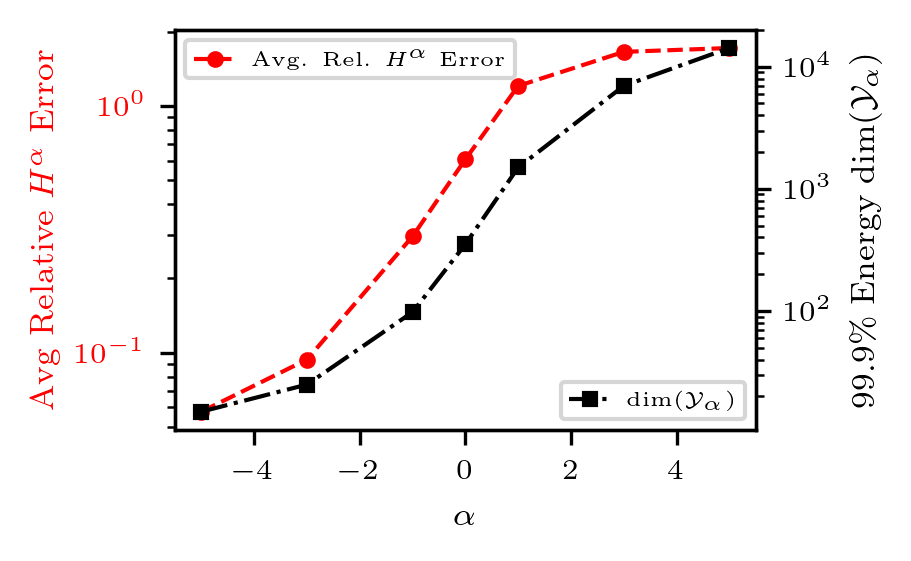

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 0.5
fig_width = textwidth_pt * pt_to_inch   *subfig_ratio         
fig_height = fig_width * 0.6                     
# Font sizes
base = 7  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base +1  
plt.rcParams["axes.titlesize"] = base + 1      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base -2        
# Markersizes
markersize_small = 1
linewidth_small = 0.5
markersize_large = 3
linewidth_large = 1 


fig,ax = plt.subplots(figsize = (fig_width, fig_height), layout = 'constrained')
ax.plot(alphas, rel_Ha_errs, 'ro--', label = r"Avg. Rel. $H^{\alpha}$ Error", markersize = markersize_large, linewidth = linewidth_large)
ax.set(xlabel=r"$\alpha$", yscale = 'log')
ax.set_ylabel(r"Avg Relative $H^{\alpha}$ Error", color = 'r')
ax.tick_params(axis = 'y', labelcolor = 'r')
ax.legend(loc = "upper left")
ax2 = ax.twinx()
ax2.plot(alphas, Y_dims, "s-.", color = 'black', label = r"$\dim(\mathcal{Y}_{\alpha})$", markersize = markersize_large, linewidth = linewidth_large)
ax2.legend(loc = 4)
ax2.set(ylabel=r"$99.9\%$ Energy $\dim(\mathcal{Y}_{\alpha})$", yscale = 'log')

plt.savefig("Plots/NS_err.pdf")
plt.show()